# Proximity Analysis

Goal: Understand how predicted graphs compare to ground truth graphs with respect to proximity of nodes.
This affects the node matching process:
1) If no GT node is within a proximity (=vessel radius of node) of a predicted node then there will be no matching.
2) If multiple GT nodes lie within a proximity we need a rule how to select the "best" proximal GT node for matching.

In this notebook we create a table that shows the following for every source (i.e. prediction) graph's node v:
- node index
- node radius
- number of GT candidate nodes within that radius around v
- Boolean if v has parent
- Boolean if all candidates have parents
- The distances from v to its candidates

In [32]:
import networkx as nx
import numpy as np
import pandas as pd

from project.utils import read_graph_from_file

def matching_analysis(source, target):
    source_positions = nx.get_node_attributes(source, 'coord')
    source_radii = nx.get_node_attributes(source, 'radius')
    target_positions = nx.get_node_attributes(target, 'coord')
    if not source_positions or not target_positions:
        raise ValueError("Both source and target graphs must have 'coord' attributes for nodes.")

    data = {
        "node" : [],
        "radius" : [],
        "nr_candidates" : [],
        "v_has_parent" : [],
        "candidates_have_parent" : [],
        "dist_to_cands" : [],
        #"parents_dist": [],
    }
    for source_node, source_pos in source_positions.items():
        radius = source_radii[source_node]
        candidates = {t_node : t_pos for t_node, t_pos in target_positions.items() if np.linalg.norm(np.array(source_pos) - np.array(t_pos)) < radius}

        def has_parent(graph, node):
            return len(list(graph.predecessors(node))) > 0
        
        cand_parents = [has_parent(target, t_node) for t_node in candidates.keys()] 
        dist_to_cands = [float(np.linalg.norm(np.array(source_pos) - np.array(t_pos))) for t_pos in candidates.values()]

        data["node"].append(source_node)
        data["radius"].append(radius)
        data["nr_candidates"].append(len(candidates))
        data["v_has_parent"].append(has_parent(source, source_node))
        data["candidates_have_parent"].append(all(cand_parents))
        data["dist_to_cands"].append(dist_to_cands)
    return pd.DataFrame(data)

The following block returns a table of the relevant information per predicted node.

In [33]:
gt = read_graph_from_file("data/38_BP_GT.swc")
pred = read_graph_from_file("data/38_BP_ours.swc")

match_pd = matching_analysis(pred, gt)
match_pd


,node,radius,nr_candidates,v_has_parent,candidates_have_parent,dist_to_cands
0,1,1.000000,0,False,True,[]
1,2,1.000000,0,True,True,[]
2,3,5.830952,1,False,False,[0.4949168899231623]
3,4,1.000000,0,True,True,[]
4,5,5.385165,0,True,True,[]
...,...,...,...,...,...,...
3833,3834,1.000000,0,True,True,[]
3834,3835,1.000000,0,True,True,[]
3835,3836,1.000000,0,True,True,[]
3836,3837,1.000000,1,True,True,[0.9908127827402016]


## Observation
Let's see how many predicted nodes have more than one GT candidates, or zero candidates

In [13]:
match_pd[match_pd["nr_candidates"]>1]

,node,radius,nr_candidates,v_has_parent,candidates_have_parent,dist_to_cands
175,176,2.000000,2,True,True,"[1.3955254848625398, 1.399572826214195]"
521,522,2.449490,2,True,True,"[1.9502586012347662, 2.160931147813993]"
1231,1232,2.000000,2,True,True,"[1.370498608060762, 1.3240504250337117]"
1302,1303,4.000000,2,True,True,"[2.6809578628616353, 3.6428719246948646]"
1309,1310,4.000000,2,True,True,"[3.593800944430191, 2.76441720124757]"
2007,2008,4.690416,3,True,True,"[3.707879756269759, 2.597854669938806, 3.57568..."
2852,2853,4.000000,2,True,True,"[3.0396568866700644, 1.7672065647732236]"
2959,2960,4.472136,2,True,True,"[1.8178279754973807, 3.1761922859911356]"
2969,2970,4.242641,2,True,True,"[2.09420100264527, 2.3540536681505975]"
3341,3342,2.000000,2,True,True,"[1.5933477829614846, 1.8895270986358699]"


In [17]:
unmatched = match_pd[match_pd["nr_candidates"]==0]
unmatched

,node,radius,nr_candidates,v_has_parent,candidates_have_parent,dist_to_cands
0,1,1.000000,0,False,True,[]
1,2,1.000000,0,True,True,[]
3,4,1.000000,0,True,True,[]
4,5,5.385165,0,True,True,[]
6,7,1.000000,0,True,True,[]
...,...,...,...,...,...,...
3832,3833,1.000000,0,True,True,[]
3833,3834,1.000000,0,True,True,[]
3834,3835,1.000000,0,True,True,[]
3835,3836,1.000000,0,True,True,[]


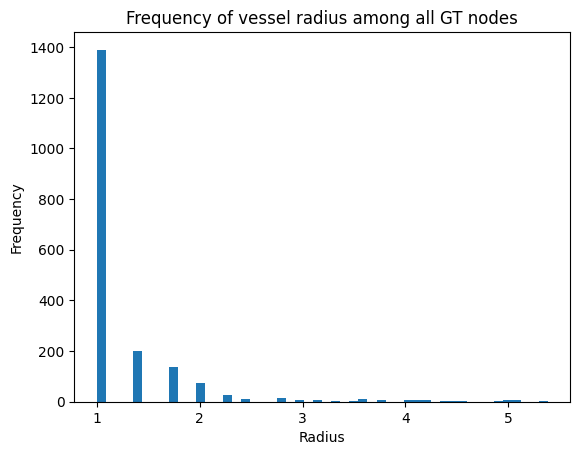

In [50]:
unm_list = unmatched["radius"].tolist()

# plot radius distribution as sorted line graph
import matplotlib.pyplot as plt
plt.hist(unm_list, bins=50)
# Name axes
plt.xlabel("Radius")
plt.ylabel("Frequency")
# Show the plot
plt.title("Frequency of vessel radius among all GT nodes")
plt.show()